In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [89]:
df = pd.read_csv('/content/sen.csv')

In [90]:
df

,sensor_id,sensor_reading,control_value,temperature,pressure,humidity,performance_metric,env_index,adjusted_sensor
0,103,107.20,51,30.82,1018.93,69.07,158.20,338.728,161.8720
1,436,118.86,39,31.90,1007.78,73.60,157.86,337.174,165.2154
2,349,105.47,52,26.69,1025.11,44.62,157.47,331.595,160.3144
3,271,117.57,64,19.36,1004.81,42.15,181.57,321.832,192.8148
4,107,95.13,29,20.36,999.88,73.97,124.13,330.299,122.7177
...,...,...,...,...,...,...,...,...,...
999995,415,85.35,61,27.89,1024.01,34.01,146.35,328.562,137.4135
999996,494,92.56,47,19.93,1008.53,74.50,139.56,332.881,136.0632
999997,335,85.92,65,27.83,1016.02,35.29,150.92,326.525,141.7680
999998,322,108.40,60,17.66,1035.48,43.64,168.40,330.800,173.4400


In [91]:
df.shape

(1000000, 9)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   sensor_id           1000000 non-null  int64  
 1   sensor_reading      1000000 non-null  float64
 2   control_value       1000000 non-null  int64  
 3   temperature         1000000 non-null  float64
 4   pressure            1000000 non-null  float64
 5   humidity            1000000 non-null  float64
 6   performance_metric  1000000 non-null  float64
 7   env_index           1000000 non-null  float64
 8   adjusted_sensor     1000000 non-null  float64
dtypes: float64(7), int64(2)
memory usage: 68.7 MB


In [93]:
df.describe()

,sensor_id,sensor_reading,control_value,temperature,pressure,humidity,performance_metric,env_index,adjusted_sensor
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,250.539749,100.000359,50.007403,25.002753,1013.022642,50.035386,150.007762,328.918509,150.008707
std,144.253011,15.006399,7.070789,4.999028,10.000666,17.314343,16.593408,6.322930,23.622955
min,1.000000,24.270000,22.000000,0.520000,961.980000,20.000000,71.580000,304.813000,37.618500
25%,126.000000,89.890000,45.000000,21.640000,1006.280000,35.050000,138.790000,324.222000,133.950000
50%,250.000000,100.010000,50.000000,25.010000,1013.010000,50.030000,149.960000,328.915000,149.683500
75%,376.000000,110.090000,55.000000,28.370000,1019.770000,65.040000,161.170000,333.621000,165.701200
max,500.000000,169.930000,86.000000,49.640000,1062.000000,80.000000,228.490000,351.787000,269.162800


In [94]:
df.columns

Index(['sensor_id', 'sensor_reading', 'control_value', 'temperature',
       'pressure', 'humidity', 'performance_metric', 'env_index',
       'adjusted_sensor'],
      dtype='object')

In [95]:
df.isnull().sum()

,0
sensor_id,0
sensor_reading,0
control_value,0
temperature,0
pressure,0
humidity,0
performance_metric,0
env_index,0
adjusted_sensor,0


In [96]:
from scipy import stats

In [97]:
duplicate_rows = df[df.duplicated()]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")

Number of duplicate rows: 0


In [98]:
df.drop_duplicates(inplace=True)

In [99]:
df.isnull().sum()

,0
sensor_id,0
sensor_reading,0
control_value,0
temperature,0
pressure,0
humidity,0
performance_metric,0
env_index,0
adjusted_sensor,0


In [100]:
# Fill missing values with median of each column
df.fillna(df.median(), inplace=True)

In [101]:

# Compute additional column 'combined_value'
df['combined_value'] = df['sensor_reading'] + df['control_value']

In [102]:
df

,sensor_id,sensor_reading,control_value,temperature,pressure,humidity,performance_metric,env_index,adjusted_sensor,combined_value
0,103,107.20,51,30.82,1018.93,69.07,158.20,338.728,161.8720,158.20
1,436,118.86,39,31.90,1007.78,73.60,157.86,337.174,165.2154,157.86
2,349,105.47,52,26.69,1025.11,44.62,157.47,331.595,160.3144,157.47
3,271,117.57,64,19.36,1004.81,42.15,181.57,321.832,192.8148,181.57
4,107,95.13,29,20.36,999.88,73.97,124.13,330.299,122.7177,124.13
...,...,...,...,...,...,...,...,...,...,...
999995,415,85.35,61,27.89,1024.01,34.01,146.35,328.562,137.4135,146.35
999996,494,92.56,47,19.93,1008.53,74.50,139.56,332.881,136.0632,139.56
999997,335,85.92,65,27.83,1016.02,35.29,150.92,326.525,141.7680,150.92
999998,322,108.40,60,17.66,1035.48,43.64,168.40,330.800,173.4400,168.40


In [103]:
df.isnull().sum()

,0
sensor_id,0
sensor_reading,0
control_value,0
temperature,0
pressure,0
humidity,0
performance_metric,0
env_index,0
adjusted_sensor,0
combined_value,0


In [104]:
# Compute required statistics
stats_df = pd.DataFrame({
    'Metric': ['Mean', 'Median', 'Mode'],
    'Sensor Reading': [df['sensor_reading'].mean(), df['sensor_reading'].median(), df['sensor_reading'].mode()[0]],
    'Control Value': [df['control_value'].mean(), df['control_value'].median(), df['control_value'].mode()[0]],
    'Combined Value': [df['combined_value'].mean(), df['combined_value'].median(), df['combined_value'].mode()[0]]
})

In [105]:
stats_df

,Metric,Sensor Reading,Control Value,Combined Value
0,Mean,100.000359,50.007403,150.007762
1,Median,100.010000,50.000000,149.960000
2,Mode,104.380000,50.000000,150.780000


<Figure size 1900x500 with 0 Axes>

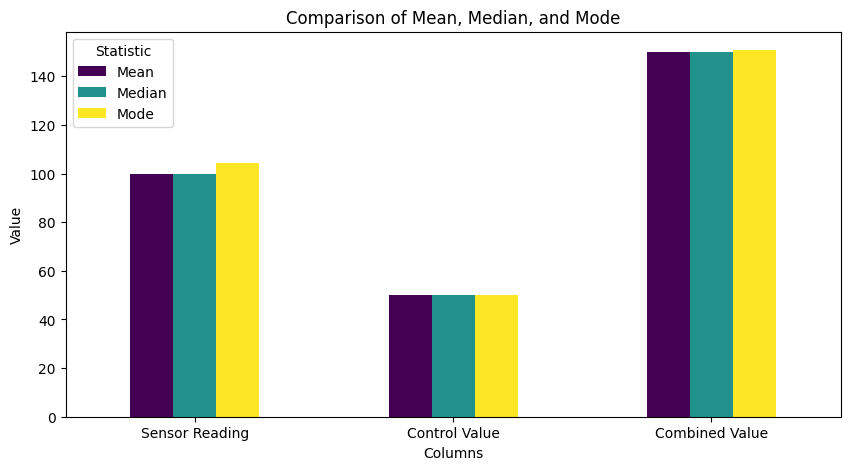

In [106]:

# Visualization
plt.figure(figsize=(19, 5))
stats_df.set_index('Metric').T.plot(kind='bar', figsize=(10, 5), colormap='viridis')
plt.title("Comparison of Mean, Median, and Mode")
plt.ylabel("Value")
plt.xlabel("Columns")
plt.xticks(rotation=0)
plt.legend(title="Statistic")
plt.show()

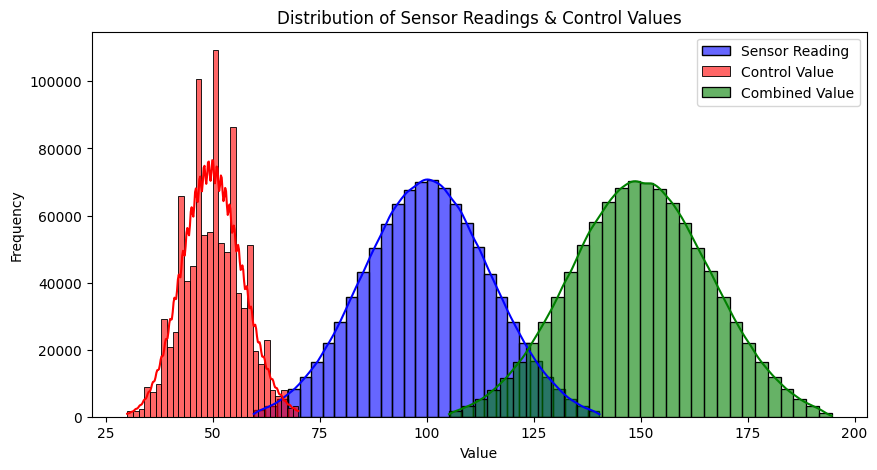

In [130]:
plt.figure(figsize=(10,5))
sns.histplot(df["sensor_reading"], bins=30, kde=True, color='blue', label="Sensor Reading", alpha=0.6)
sns.histplot(df["control_value"], bins=30, kde=True, color='red', label="Control Value", alpha=0.6)
sns.histplot(df["combined_value"], bins=30, kde=True, color='green', label="Combined Value", alpha=0.6)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Distribution of Sensor Readings & Control Values")
plt.legend()
plt.show()


In [107]:
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.set_index('timestamp', inplace=True)
    plt.figure(figsize=(12,6))
    plt.plot(df.index, df["sensor_reading"], label="Sensor Reading", color="blue", alpha=0.7)
    plt.plot(df.index, df["control_value"], label="Control Value", color="red", alpha=0.7)
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title("Time Series Trend of Sensor Readings & Control Values")
    plt.legend()
    plt.show()


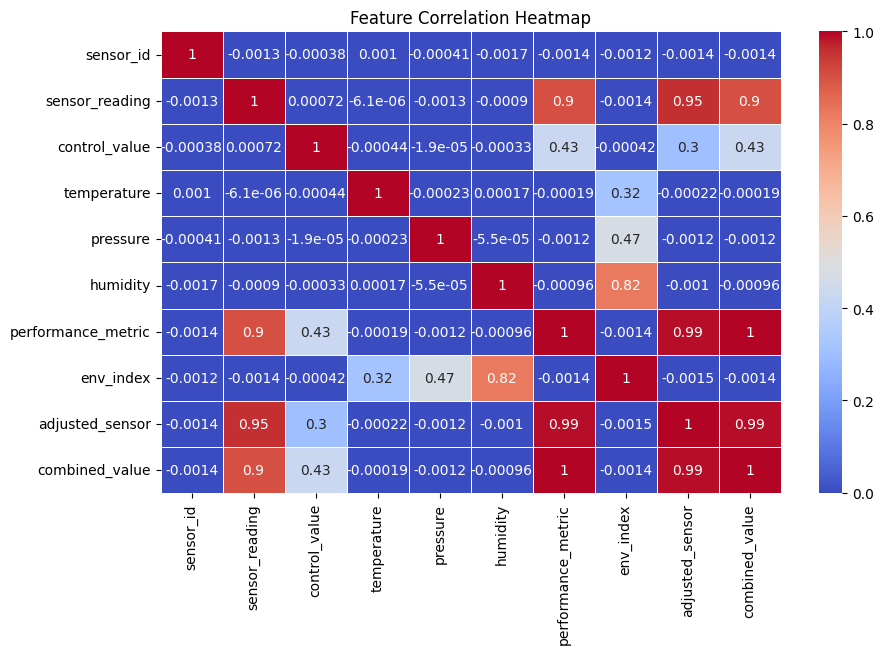

In [108]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


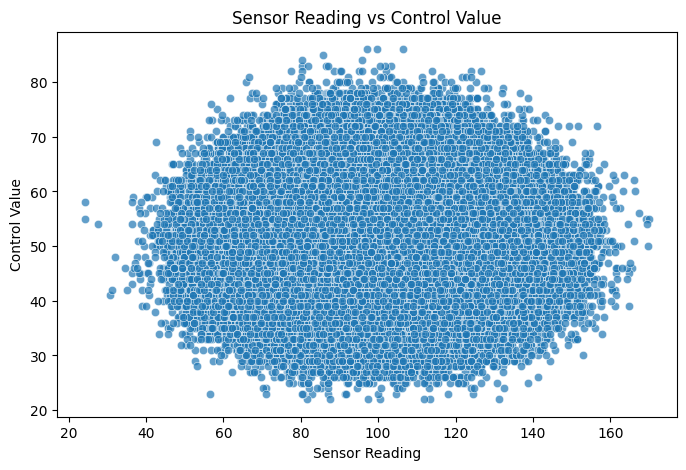

In [109]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["sensor_reading"], y=df["control_value"], alpha=0.7)
plt.xlabel("Sensor Reading")
plt.ylabel("Control Value")
plt.title("Sensor Reading vs Control Value")
plt.show()


# Additionally Things Performs

In [110]:
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import ttest_ind

In [111]:
# Handling Missing Values using KNN Imputation
imputer = KNNImputer(n_neighbors=5)
df.iloc[:, 1:] = imputer.fit_transform(df.iloc[:, 1:])

In [113]:
df.shape

(1000000, 10)

In [114]:
# Outlier Detection using IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [115]:
# Feature Engineering
df['rolling_avg_sensor'] = df['sensor_reading'].rolling(window=5).mean()
df['rolling_avg_control'] = df['control_value'].rolling(window=5).mean()
df['performance_score'] = (df['performance_metric'] + df['env_index'] + df['adjusted_sensor']) / 3

<ipython-input-115-3dd8d897db11>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rolling_avg_sensor'] = df['sensor_reading'].rolling(window=5).mean()
<ipython-input-115-3dd8d897db11>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rolling_avg_control'] = df['control_value'].rolling(window=5).mean()
<ipython-input-115-3dd8d897db11>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

In [116]:
# Deep Statistical Insights
skewness = df[['sensor_reading', 'control_value', 'combined_value']].skew()
kurtosis = df[['sensor_reading', 'control_value', 'combined_value']].kurt()
variance = df[['sensor_reading', 'control_value', 'combined_value']].var()
std_dev = df[['sensor_reading', 'control_value', 'combined_value']].std()

In [117]:
# Hypothesis Testing (Comparing sensor readings across conditions)
condition_1 = df[df['temperature'] > df['temperature'].median()]['sensor_reading']
condition_2 = df[df['temperature'] <= df['temperature'].median()]['sensor_reading']
t_stat, p_value = ttest_ind(condition_1, condition_2)
print(f"T-Test: t-stat={t_stat}, p-value={p_value}")

T-Test: t-stat=-0.14380079422151648, p-value=0.8856578055351418


In [118]:
# Clustering Sensors
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[['sensor_reading', 'control_value', 'performance_score']])
kmeans = KMeans(n_clusters=3, random_state=42)
df['sensor_cluster'] = kmeans.fit_predict(df_scaled)

In [119]:
# Anomaly Detection using Isolation Forest
iso_forest = IsolationForest(contamination=0.01)
df["anomaly"] = iso_forest.fit_predict(df[['sensor_reading', 'control_value', 'combined_value']])
anomalies = df[df["anomaly"] == -1]
print(f"Total Anomalies Detected: {len(anomalies)}")

Total Anomalies Detected: 9677


In [120]:
# Predictive Modeling (Linear Regression for performance_metric)
X = df[['sensor_reading', 'control_value', 'temperature', 'humidity']]
y = df['performance_metric']
model = LinearRegression()
model.fit(X, y)
predictions = model.predict(X)
df["predicted_performance_metric"] = predictions

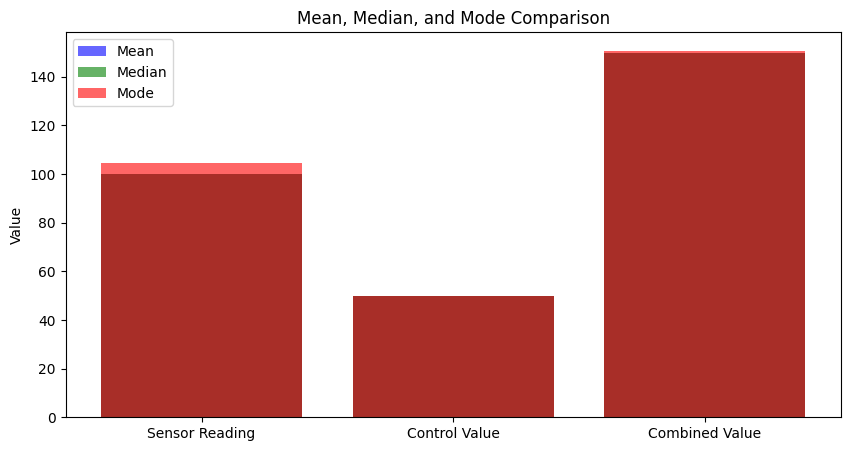

In [121]:
# Visualization
fig, ax = plt.subplots(figsize=(10,5))
labels = ['Sensor Reading', 'Control Value', 'Combined Value']
ax.bar(labels, df[['sensor_reading', 'control_value', 'combined_value']].mean(), color='blue', alpha=0.6, label='Mean')
ax.bar(labels, df[['sensor_reading', 'control_value', 'combined_value']].median(), color='green', alpha=0.6, label='Median')
ax.bar(labels, df[['sensor_reading', 'control_value', 'combined_value']].mode().iloc[0], color='red', alpha=0.6, label='Mode')
ax.set_ylabel("Value")
ax.set_title("Mean, Median, and Mode Comparison")
ax.legend()
plt.show()


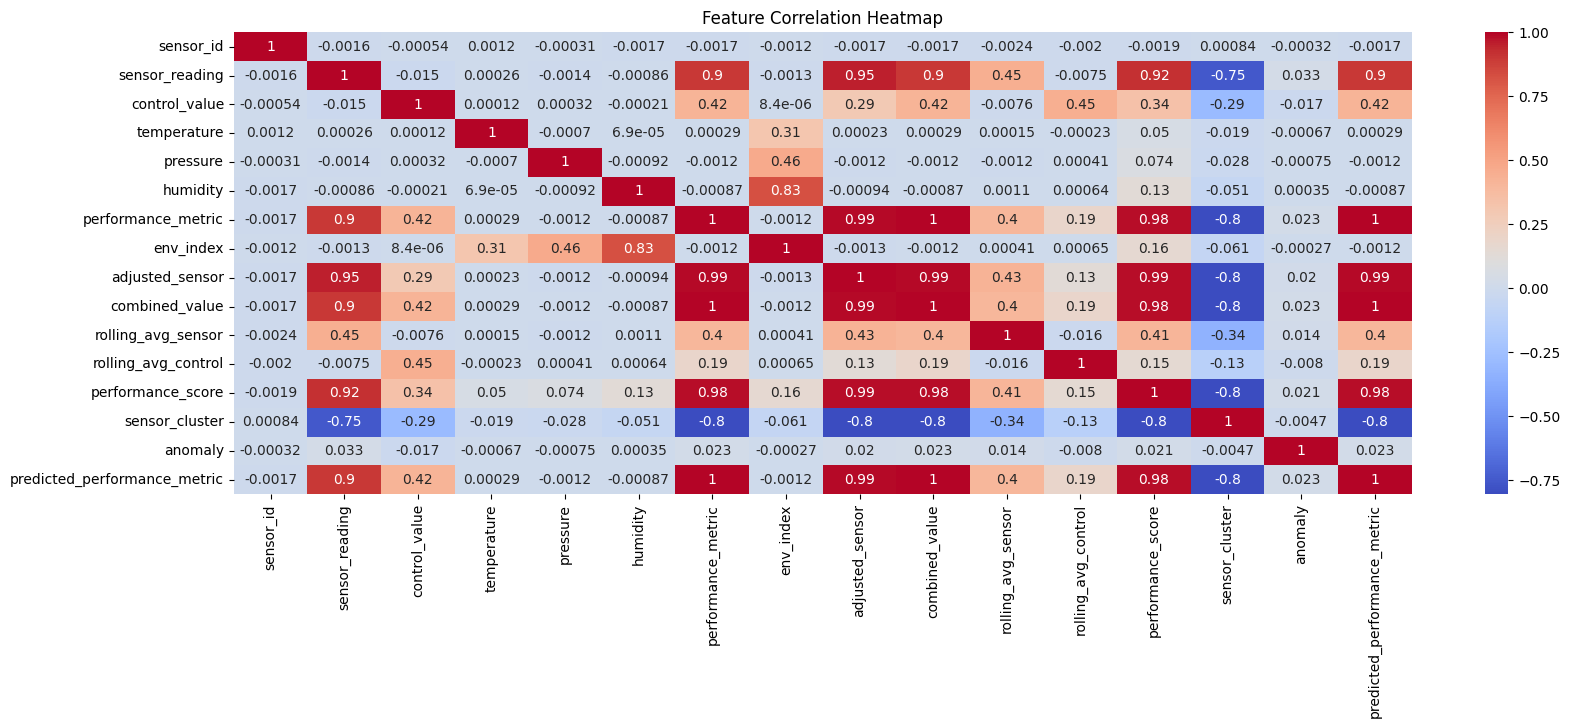

In [122]:
# Correlation Heatmap
plt.figure(figsize=(19,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

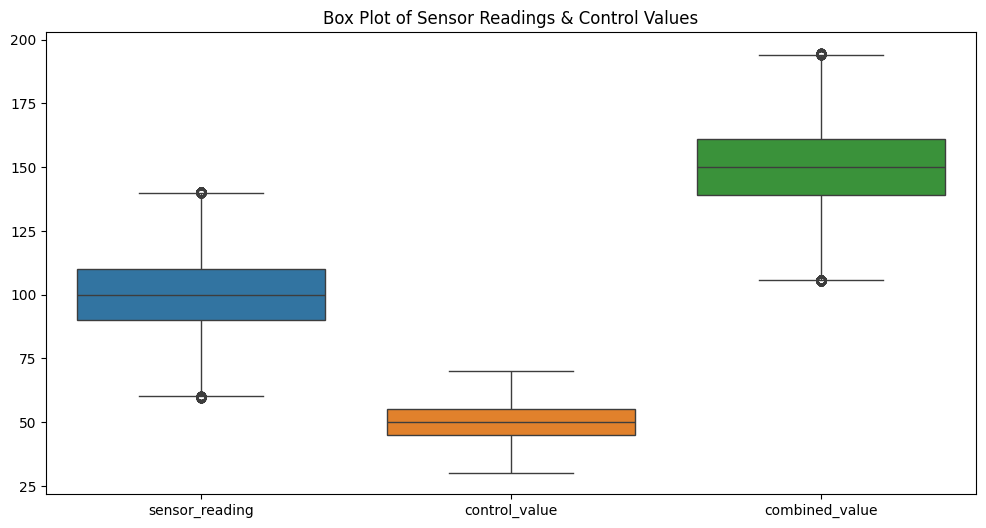

In [123]:
# Boxplot for Outlier Detection
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['sensor_reading', 'control_value', 'combined_value']])
plt.title("Box Plot of Sensor Readings & Control Values")
plt.show()


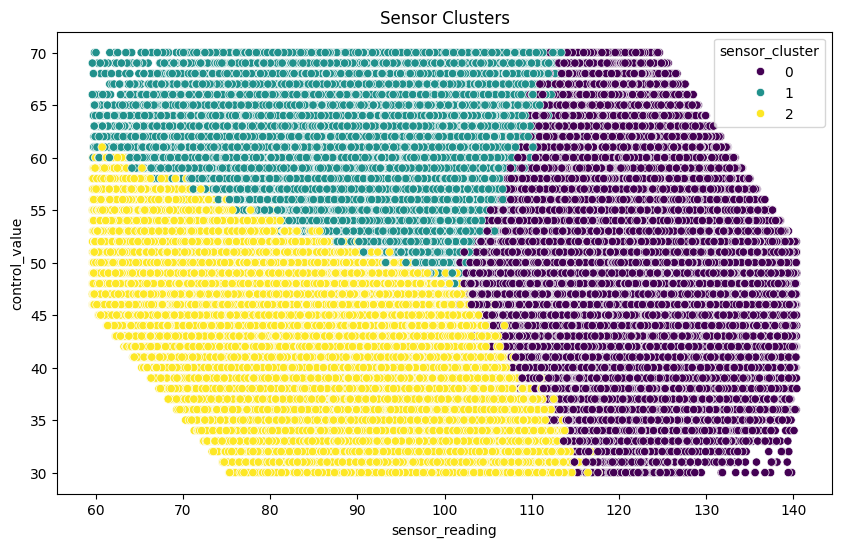

In [124]:

# Clustering Visualization
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['sensor_reading'], y=df['control_value'], hue=df['sensor_cluster'], palette='viridis')
plt.title("Sensor Clusters")
plt.show()

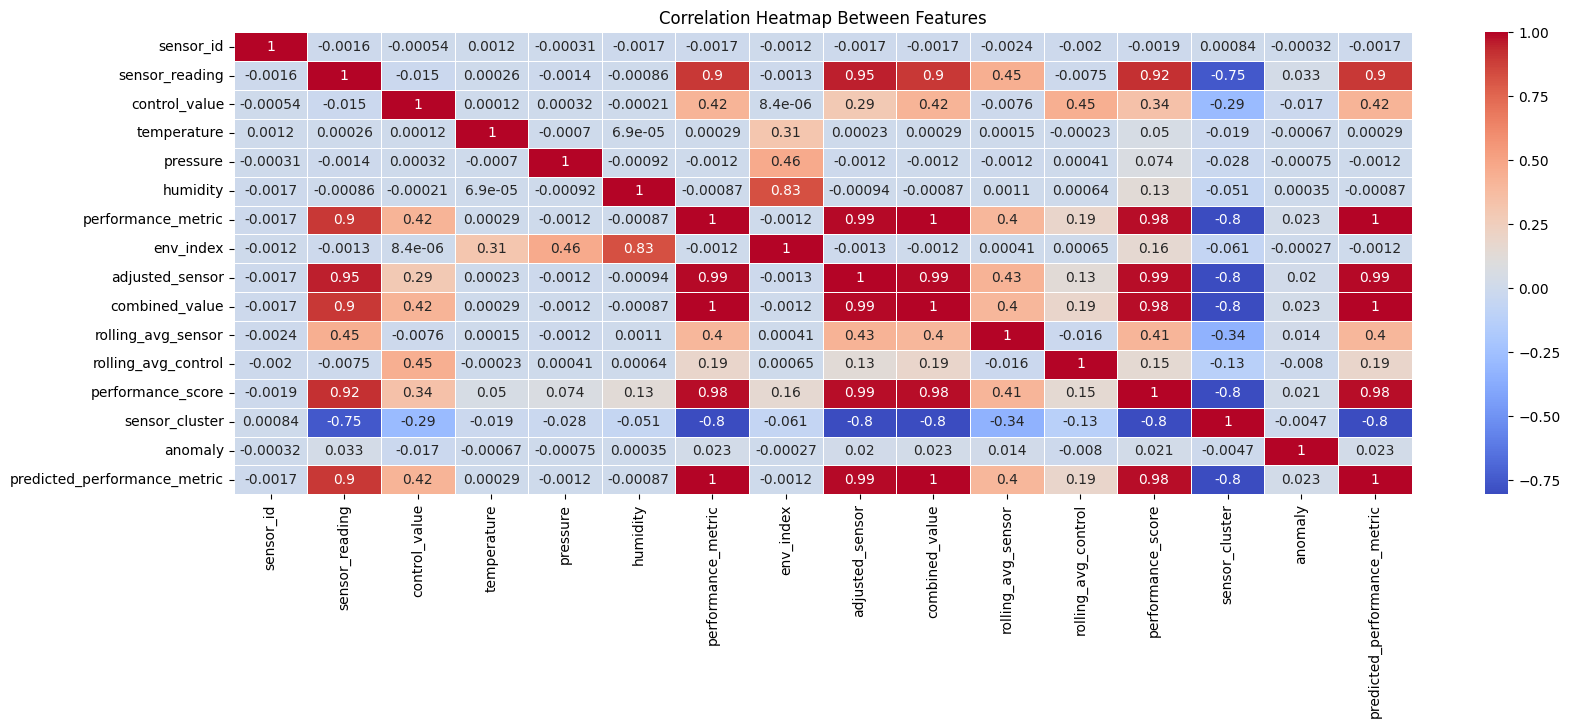

In [126]:
plt.figure(figsize=(19,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap Between Features")
plt.show()


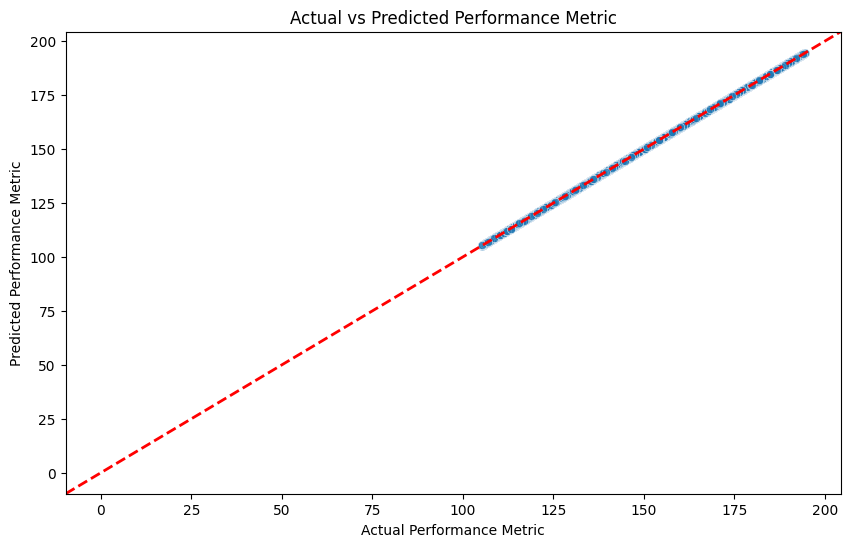

In [127]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df["performance_metric"], y=df["predicted_performance_metric"], alpha=0.7)
plt.xlabel("Actual Performance Metric")
plt.ylabel("Predicted Performance Metric")
plt.title("Actual vs Predicted Performance Metric")
plt.axline([0, 0], [1, 1], color='red', linestyle="--", linewidth=2)  # Ideal Prediction Line
plt.show()
